# M2-B2 — Audit éthique Athéna RH — phase SYNC binôme

> **Mission** : audit éthique complet du dataset Adult Income enrichi de
> commentaires manager. Datasheet duo signée. La phase d'anonymisation
> personnelle se fera en async (notebook séparé).

Binôme : `<prénom1>` + `<prénom2>` — Date : `<date>`

**Conventions** :
- `random_state=42` partout
- Pas de `print` (utiliser `display()` ou laisser la cellule retourner)
- `pathlib.Path` sur les chemins

## 0. Setup

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

RANDOM_STATE = 42
DATA_DIR = Path("../data")
FULL_PATH = DATA_DIR / "adult_income_with_comments.csv"
SAMPLE_PATH = DATA_DIR / "audit_sample.csv"

sns.set_theme(style="whitegrid")

In [2]:
df = pd.read_csv(FULL_PATH)
print(f"Shape : {df.shape}")
df.head(3)

Shape : (32561, 16)


,age,workclass,fnlwgt,education,education_num,marital_status,occupation,relationship,race,sex,capital_gain,capital_loss,hours_per_week,native_country,income,manager_comments
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K,RAS pour Alexandre Traore cette année. Manager...
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K,Entretien annuel de Yves Traore : bon élément....
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K,Alerte comportementale signalée par Gabriel de...


## 1. Audit qualité express (~15 min)

Le dataset Adult est plus propre que German Credit (peu de manquants).
Survol express ici — l'audit éthique est le cœur de M2-B2.

In [3]:
# Audit qualité express (manquants, doublons, cohérence cible)
display(df.info())

missing = (
    df.isna().sum()
    .rename("missing_count")
    .to_frame()
    .assign(missing_rate=lambda x: (x["missing_count"] / len(df)).round(4))
    .sort_values("missing_count", ascending=False)
 )

display(missing.head(10))

duplicate_rows = df.duplicated().sum()
quality_kpis = pd.DataFrame(
    {
        "kpi": ["n_rows", "n_cols", "duplicate_rows", "target_unique_values"],
        "value": [len(df), df.shape[1], int(duplicate_rows), df["income"].nunique()],
    }
)
display(quality_kpis)

target_dist = (
    df["income"]
    .value_counts(normalize=True)
    .rename("share")
    .to_frame()
    .assign(share=lambda x: (100 * x["share"]).round(2))
 )
display(target_dist)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32561 entries, 0 to 32560
Data columns (total 16 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   age               32561 non-null  int64 
 1   workclass         30725 non-null  object
 2   fnlwgt            32561 non-null  int64 
 3   education         32561 non-null  object
 4   education_num     32561 non-null  int64 
 5   marital_status    32561 non-null  object
 6   occupation        30718 non-null  object
 7   relationship      32561 non-null  object
 8   race              32561 non-null  object
 9   sex               32561 non-null  object
 10  capital_gain      32561 non-null  int64 
 11  capital_loss      32561 non-null  int64 
 12  hours_per_week    32561 non-null  int64 
 13  native_country    31978 non-null  object
 14  income            32561 non-null  object
 15  manager_comments  32561 non-null  object
dtypes: int64(6), object(10)
memory usage: 4.0+ MB


None

,missing_count,missing_rate
occupation,1843,0.0566
workclass,1836,0.0564
native_country,583,0.0179
age,0,0.0000
fnlwgt,0,0.0000
education,0,0.0000
education_num,0,0.0000
marital_status,0,0.0000
relationship,0,0.0000
race,0,0.0000


,kpi,value
0,n_rows,32561
1,n_cols,16
2,duplicate_rows,0
3,target_unique_values,2


,share
income,
<=50K,75.92
>50K,24.08


### Synthèse qualité express

- Taille du dataset : **32 561 lignes** et **16 colonnes**.
- Doublons exacts : **0**.
- Valeurs manquantes concentrées sur 3 colonnes :
  - `occupation` : 1 843 (~5,66 %)
  - `workclass` : 1 836 (~5,64 %)
  - `native_country` : 583 (~1,79 %)
- Cible `income` binaire et déséquilibrée : **75,92 % `<=50K`** vs **24,08 % `>50K`**.

Conclusion : le dataset est globalement exploitable pour l'audit éthique, avec un point d'attention sur les NA de variables socio-professionnelles.

### Décision de modélisation (redondance éducation)

Pour les usages de modélisation, nous conserverons **uniquement `education_num`** et nous exclurons **`education`**.

Justification : `education` (catégorielle) et `education_num` (codage ordinal du niveau d'études) portent la même information métier ; les garder ensemble introduit une redondance inutile et un risque de double comptage du signal.

## 2. Audit éthique complet (~1 h)

Calcul du **disparate impact** sur 3 variables sensibles + 1 intersection.

In [10]:
def disparate_impact_vs_overall(
    df: pd.DataFrame, sensible: str, target: str = "income", positive: str = ">50K"
 ) -> tuple[float, pd.Series, pd.Series]:
    """Retourne le taux global, les taux par groupe et le ratio SR_groupe / SR_global."""
    sr_global = (df[target] == positive).mean()
    sr_group = df.groupby(sensible)[target].apply(lambda x: (x == positive).mean())
    di_vs_overall = sr_group / sr_global
    return sr_global, sr_group, di_vs_overall

In [11]:
sr_global, sr_sex, di_sex = disparate_impact_vs_overall(df, "sex")

sex_table = pd.DataFrame(
    {
        "selection_rate_>50K": sr_sex,
        "DI_vs_overall": di_sex,
    }
).sort_values("selection_rate_>50K", ascending=False)

display(pd.DataFrame({"global_selection_rate_>50K": [round(sr_global, 4)]}))
display(sex_table.round(3))

,global_selection_rate_>50K
0,0.2408


,selection_rate_>50K,DI_vs_overall
sex,,
Male,0.306,1.270
Female,0.109,0.455


In [12]:
# DI par race en excluant explicitement la modalite "Other"
df_race = df.loc[df["race"].ne("Other")].copy()
sr_global_race, sr_race, di_race = disparate_impact_vs_overall(df_race, "race")

race_table = pd.DataFrame(
    {
        "selection_rate_>50K": sr_race,
        "DI_vs_overall": di_race,
    }
).sort_values("selection_rate_>50K", ascending=False)

# Matrice de comparaison pairwise entre races
races = race_table.index.tolist()
di_matrix = pd.DataFrame(index=races, columns=races, dtype=float)
for r1 in races:
    for r2 in races:
        sr1, sr2 = race_table.loc[r1, "selection_rate_>50K"], race_table.loc[r2, "selection_rate_>50K"]
        di_matrix.loc[r1, r2] = min(sr1, sr2) / max(sr1, sr2)

display(pd.DataFrame({"global_selection_rate_>50K_without_other": [round(sr_global_race, 4)]}))
display(race_table.round(3))
display(di_matrix.round(3))

,global_selection_rate_>50K_without_other
0,0.2421


,selection_rate_>50K,DI_vs_overall
race,,
Asian-Pac-Islander,0.266,1.097
White,0.256,1.057
Black,0.124,0.512
Amer-Indian-Eskimo,0.116,0.478


,Asian-Pac-Islander,White,Black,Amer-Indian-Eskimo
Asian-Pac-Islander,1.000,0.963,0.466,0.436
White,0.963,1.000,0.484,0.452
Black,0.466,0.484,1.000,0.934
Amer-Indian-Eskimo,0.436,0.452,0.934,1.000


In [13]:
df["native_us"] = np.where(df["native_country"].eq("United-States"), "USA", "non-USA")
sr_global, sr_native, di_native = disparate_impact_vs_overall(df, "native_us")

native_table = pd.DataFrame(
    {
        "selection_rate_>50K": sr_native,
        "DI_vs_overall": di_native,
    }
).sort_values("selection_rate_>50K", ascending=False)

display(pd.DataFrame({"global_selection_rate_>50K": [round(sr_global, 4)]}))
display(native_table.round(3))

,global_selection_rate_>50K
0,0.2408


,selection_rate_>50K,DI_vs_overall
native_us,,
USA,0.246,1.021
non-USA,0.198,0.820


### Intersectionnalité — DI sur le croisement sex × race

In [14]:
df["sex_race"] = df["sex"].str.cat(df["race"], sep="_")
sr_global, sr_intersection, di_intersection = disparate_impact_vs_overall(df, "sex_race")

intersection_table = pd.DataFrame(
    {
        "selection_rate_>50K": sr_intersection,
        "DI_vs_overall": di_intersection,
    }
).sort_values("selection_rate_>50K", ascending=False)

display(pd.DataFrame({"global_selection_rate_>50K": [round(sr_global, 4)]}))
display(intersection_table.round(3))

,global_selection_rate_>50K
0,0.2408


,selection_rate_>50K,DI_vs_overall
sex_race,,
Male_Asian-Pac-Islander,0.336,1.396
Male_White,0.318,1.319
Male_Black,0.189,0.786
Male_Amer-Indian-Eskimo,0.125,0.519
Female_Asian-Pac-Islander,0.124,0.516
Female_White,0.119,0.494
Male_Other,0.117,0.487
Female_Amer-Indian-Eskimo,0.101,0.419
Female_Black,0.058,0.240


## 3. Visualisations (≥ 5)

Au moins 5 visualisations : distribution cible + DI par variable sensible +
crosstab intersection.

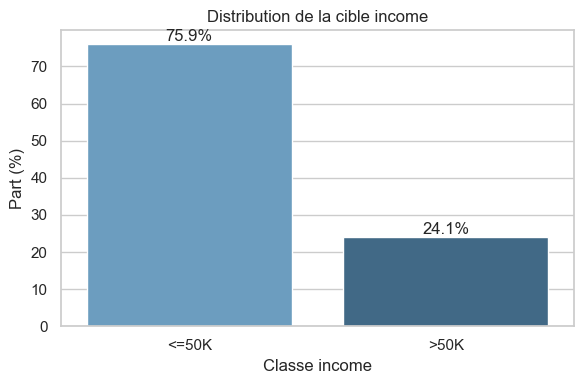

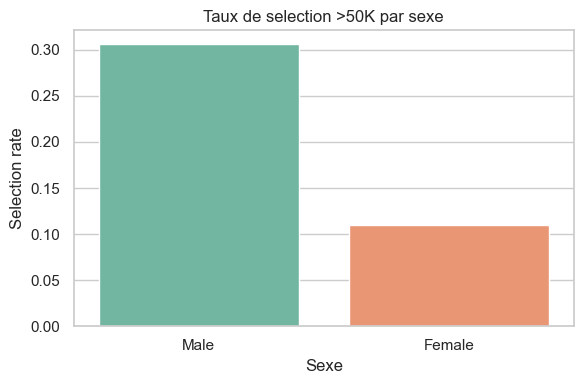

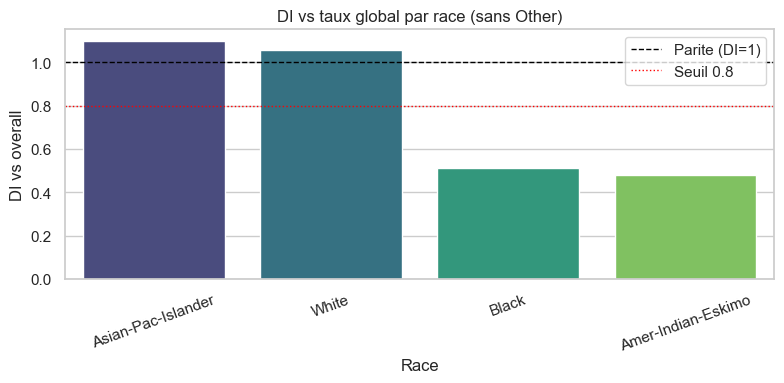

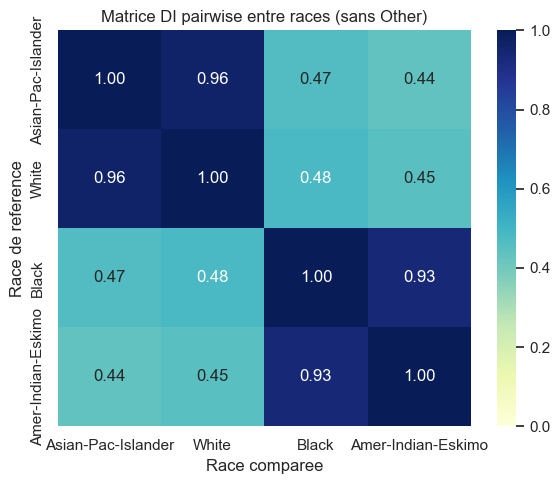

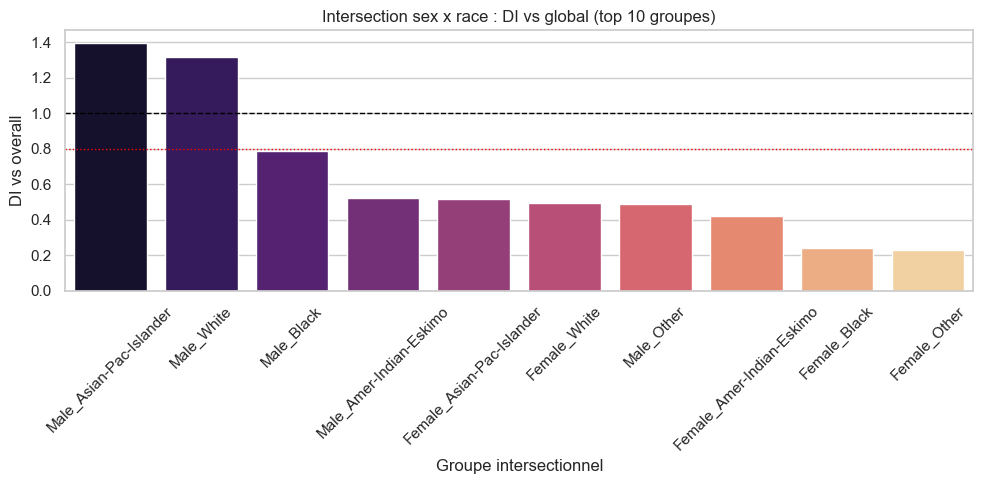

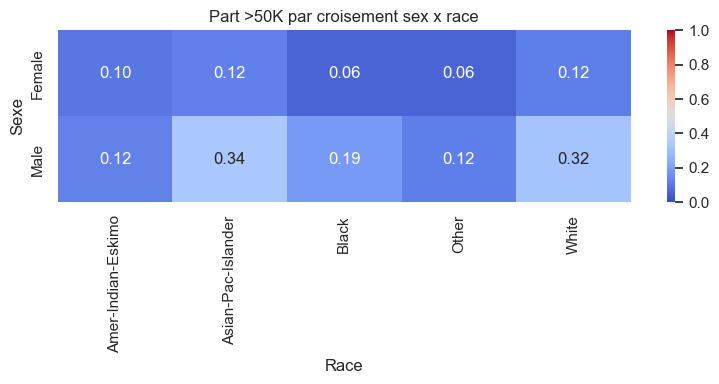

In [16]:
# 1) Distribution de la cible income
plt.figure(figsize=(6, 4))
income_dist = (
    df["income"].value_counts(normalize=True).mul(100).rename_axis("income").reset_index(name="percent")
)
ax = sns.barplot(data=income_dist, x="income", y="percent", hue="income", palette="Blues_d", legend=False)
ax.set_title("Distribution de la cible income")
ax.set_xlabel("Classe income")
ax.set_ylabel("Part (%)")
for container in ax.containers:
    ax.bar_label(container, fmt="%.1f%%")
plt.tight_layout()
plt.show()

# 2) Taux de selection >50K par sexe
plt.figure(figsize=(6, 4))
sex_plot = sex_table.reset_index()
sex_col = sex_plot.columns[0]
ax = sns.barplot(data=sex_plot, x=sex_col, y="selection_rate_>50K", hue=sex_col, palette="Set2", legend=False)
ax.set_title("Taux de selection >50K par sexe")
ax.set_xlabel("Sexe")
ax.set_ylabel("Selection rate")
plt.tight_layout()
plt.show()

# 3) DI vs overall par race (sans Other)
plt.figure(figsize=(8, 4))
race_plot = race_table.reset_index()
race_col = race_plot.columns[0]
ax = sns.barplot(data=race_plot, x=race_col, y="DI_vs_overall", hue=race_col, palette="viridis", legend=False)
ax.axhline(1.0, color="black", linestyle="--", linewidth=1, label="Parite (DI=1)")
ax.axhline(0.8, color="red", linestyle=":", linewidth=1, label="Seuil 0.8")
ax.set_title("DI vs taux global par race (sans Other)")
ax.set_xlabel("Race")
ax.set_ylabel("DI vs overall")
ax.tick_params(axis="x", rotation=20)
ax.legend()
plt.tight_layout()
plt.show()

# 4) Heatmap matrice DI pairwise entre races
plt.figure(figsize=(6, 5))
sns.heatmap(di_matrix, annot=True, fmt=".2f", cmap="YlGnBu", vmin=0, vmax=1)
plt.title("Matrice DI pairwise entre races (sans Other)")
plt.xlabel("Race comparee")
plt.ylabel("Race de reference")
plt.tight_layout()
plt.show()

# 5) DI vs overall pour les groupes intersectionnels (top 10)
plt.figure(figsize=(10, 5))
intersection_top = intersection_table.head(10).reset_index()
intersection_col = intersection_top.columns[0]
ax = sns.barplot(data=intersection_top, x=intersection_col, y="DI_vs_overall", hue=intersection_col, palette="magma", legend=False)
ax.axhline(1.0, color="black", linestyle="--", linewidth=1)
ax.axhline(0.8, color="red", linestyle=":", linewidth=1)
ax.set_title("Intersection sex x race : DI vs global (top 10 groupes)")
ax.set_xlabel("Groupe intersectionnel")
ax.set_ylabel("DI vs overall")
ax.tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.show()

# 6) Crosstab intersection sex x race sur la part >50K
pivot_inter = pd.crosstab(
    df["sex"],
    df["race"],
    values=(df["income"] == ">50K").astype(int),
    aggfunc="mean",
)
plt.figure(figsize=(8, 4))
sns.heatmap(pivot_inter, annot=True, fmt=".2f", cmap="coolwarm", vmin=0, vmax=1)
plt.title("Part >50K par croisement sex x race")
plt.xlabel("Race")
plt.ylabel("Sexe")
plt.tight_layout()
plt.show()

### Analyse rapide des graphiques

1. **Distribution de la cible income**
La cible est desequilibree (environ 76 % `<=50K` vs 24 % `>50K`). Ce desequilibre peut influencer l'interpretation des performances d'un modele et justifie un suivi des metriques par sous-groupes.

2. **Taux de selection >50K par sexe**
Le taux `>50K` est nettement plus eleve chez les hommes que chez les femmes. Ce premier signal indique un ecart structurel selon le sexe.

3. **DI vs overall par race (sans Other)**
Les groupes `Asian-Pac-Islander` et `White` sont au-dessus de 1 (sur-selection relative), alors que `Black` et `Amer-Indian-Eskimo` sont bien en dessous de 0.8 (sous-selection marquee).

4. **Matrice DI pairwise entre races**
La matrice confirme des ecarts faibles entre groupes favorises (`White` vs `Asian-Pac-Islander`) et des ecarts forts entre groupes favorises et defavorises (valeurs autour de 0.44-0.48).

5. **Intersection sex x race : DI vs global**
Le croisement montre une heterogeneite plus forte que les variables prises separement : certains groupes masculins sont nettement favorises, tandis que des groupes feminins (notamment `Female_Black` et `Female_Other`) sont fortement defavorises.

6. **Heatmap part >50K par croisement sex x race**
La lecture directe des taux confirme l'effet intersectionnel : pour une meme race, les taux des femmes sont generalement plus faibles que ceux des hommes, ce qui suggere un effet cumulatif sexe + race.

## 4. Verdict éthique

### Biais structurels détectés

L'audit éthique du dataset Adult Income (32 561 lignes, 16 colonnes) révèle des biais structurels significatifs sur trois variables sensibles.

**Variable `sex`**
Le taux de sélection `>50K` est de **30,6 %** pour les hommes contre **10,9 %** pour les femmes.
Le DI vs taux global est de **0.455** pour les femmes, très en dessous du seuil critique de 0.8. Ce biais reflète des inégalités salariales et de progression de carrière documentées dans les données de recensement 1994.

**Variable `race` (sans modalité Other)**
Les groupes `Black` (DI = 0.512) et `Amer-Indian-Eskimo` (DI = 0.478) sont nettement sous-représentés dans la tranche haute de revenus par rapport au taux global (24,2 % hors Other).
À l'inverse, `Asian-Pac-Islander` (DI = 1.097) et `White` (DI = 1.057) sont légèrement sur-représentés.
La matrice pairwise confirme des écarts forts entre les deux groupes favorisés et les deux groupes défavorisés (DI pairwise autour de 0.44–0.48).

**Variable `native_country` (USA / non-USA)**
Le DI vs global est de **0.820** pour le groupe non-USA, légèrement sous le seuil de 0.8. Le biais est présent mais moins sévère que sur `sex` et `race`.

### Intersection la plus problématique

Le croisement `sex × race` révèle des écarts bien plus marqués :

| Groupe | DI vs overall |
|---|---|
| Male_Asian-Pac-Islander | 1.396 (sur-sélection) |
| Male_White | 1.319 (sur-sélection) |
| Female_Black | 0.240 (forte sous-sélection) |
| Female_Other | 0.229 (forte sous-sélection) |

L'effet cumulatif sexe + race pénalise massivement les femmes des groupes minoritaires. Le groupe `Female_Other` (DI = 0.229) atteint moins du quart du taux global.

### Dimension RGPD

Ce dataset soulève plusieurs problématiques au regard du Règlement Général sur la Protection des Données (RGPD, UE 2016/679) :

**Données à caractère sensible (article 9 RGPD)**
Les colonnes `race`, `sex`, `native_country` et `marital_status` sont des **catégories spéciales de données** au sens de l'article 9 du RGPD :

| Colonne | Catégorie RGPD art. 9 |
|---|---|
| `race` | Origine raciale ou ethnique |
| `sex` | Donnée à caractère personnel (sexe) |
| `native_country` | Origine nationale |
| `marital_status` | Indirectement liée à la vie privée |

Le traitement de ces données est **en principe interdit**, sauf exception explicite (consentement, intérêt public, etc.). Les utiliser comme features dans un système de décision RH constitue un **usage prohibé** sans base légale documentée.

**Données PII dans `manager_comments`**
La colonne `manager_comments` contient des **informations personnelles identifiantes (PII)** : noms, prénoms, éventuellement des coordonnées. Leur présence en clair dans le dataset constitue une non-conformité RGPD (droit à la minimisation des données, art. 5). Une **anonymisation obligatoire** est requise avant tout usage.

**Proxy et discrimination indirecte**
Utiliser `fnlwgt` ou `education_num` comme features peut induire une **discrimination indirecte** au sens de l'article 22 RGPD relatif aux décisions automatisées. Même en retirant les colonnes sensibles, un modèle entraîné sur ce dataset peut reproduire les biais via ces proxies.

### Conclusion

**Le biais le plus problématique est l'intersection `sex × race`**, qui amplifie les désavantages individuels de chaque dimension. Un modèle entraîné naïvement sur ce dataset risquerait de reproduire et de consolider ces inégalités structurelles, et exposerait l'organisation à un risque juridique au titre du RGPD et des législations anti-discrimination.

**Recommandations** :
- Exclure `sex`, `race`, `native_country`, `marital_status` de tout modèle décisionnel RH.
- Anonymiser `manager_comments` avant tout traitement (cf. phase async).
- Exclure `fnlwgt` des features (proxy des variables sensibles).
- Documenter la base légale du traitement auprès du DPO (Laurence Béthencourt, Athéna RH).

> *À recopier dans `../datasheet.md`, section Composition / Risques.*

## 5. Aperçu de la colonne `manager_comments` (pour préparer l'async)

In [17]:
import re

comments = df["manager_comments"].fillna("")

patterns = {
    "email": r"\b[a-zA-Z0-9._%+-]+@[a-zA-Z0-9.-]+\.[a-zA-Z]{2,}\b",
    "phone": r"(?:\+?\d{1,3}[\s.-]?)?(?:\(?\d{2,4}\)?[\s.-]?)\d{2,4}[\s.-]?\d{2,4}[\s.-]?\d{2,4}",
    "date": r"\b(?:\d{1,2}[/-]\d{1,2}[/-]\d{2,4}|\d{4}-\d{2}-\d{2})\b",
    "ip": r"\b(?:\d{1,3}\.){3}\d{1,3}\b",
}

pii_counts = {
    label: comments.str.contains(pattern, regex=True).sum()
    for label, pattern in patterns.items()
}
pii_summary = pd.DataFrame(
    {
        "pii_type": list(pii_counts.keys()),
        "n_rows_detected": list(pii_counts.values()),
    }
).sort_values("n_rows_detected", ascending=False)

display(pii_summary)

sample_comments = df[["manager_comments"]].sample(8, random_state=RANDOM_STATE).reset_index(drop=True)
sample_comments.index = sample_comments.index + 1
sample_comments.index.name = "sample_id"
display(sample_comments)

,pii_type,n_rows_detected
1,phone,18233
0,email,15628
2,date,12046
3,ip,0


,manager_comments
sample_id,
1,Jennifer Stanton is a strong promotion candida...
2,Patricia Chang DDS on extended leave since 202...
3,Matthew Hawkins on extended leave since 2025-0...
4,Onboarding complete for Valerie Watson. Buddy ...
5,Onboarding complete for Shane Scott. Buddy ass...
6,Annual review for Andrew Lawrence: solid contr...
7,Behavioral concern raised by colleague Robert ...
8,PIP opened 2025-09-17. Coaching assigned to Ta...


## 6. Datasheet binôme (à compléter dans `../datasheet.md`)

Reprendre la structure Gebru — 7 sections, 2 pages max. Signée duo
(« Auteurs : <prénom1>, <prénom2> » en haut).